# 第4回　SHAPでモデルを解釈する：どの化学構造が透過性を決めるのか

機械学習モデルは通常「ブラックボックス」と呼ばれます。予測はできても、**なぜその予測になったのか**が分かりません。材料研究では、「この高分子の透過係数は3.2です」と言われるより、「メチル基を増やすと透過性が上がり、カルボニル基を入れると選択性が上がる」と教えてもらう方が役に立ちます。

本回では **SHAP (SHapley Additive exPlanations)** を使ってモデルの中身を覗き、論文 Fig.3・Fig.4 を再現します。論文 Fig.1 の **Step 3.5** に対応します。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane/blob/main/04_shap_interpretation.ipynb)

## 本ノートブックについて

| 項目 | 内容 |
| --- | --- |
| **対象読者** | 第1〜3回を終えた方 |
| **前提知識** | Pythonの基礎文法。第3回で学習した DNN アンサンブルを使います |
| **本回で学ぶこと** | ①SHAP値の考え方と加法性、②DNNアンサンブルの解釈、③記述子・部分構造から化学的な設計指針を引き出す方法、④透過性/選択性トレードオフの化学的説明 |
| **所要時間** | 約50分（SHAP値の計算に2〜3分） |
| **動作環境** | Python 3.10以上、shap / TensorFlow(Keras) / rdkit / scikit-learn |
| **モデル** | `code/pretrained_models/DNN_BLR_fing`・`DNN_BLR_desc`（著者らの学習済みアンサンブル） |
| **ライセンス** | 論文 CC BY-NC 4.0。原著コード `code/step3.5_SHAP.py`・`code/visualizations.ipynb` を教材向けに書き直しています |

> **第3回の重要な注意の再掲**
>
> 第3回で確認したとおり、これらの学習済みモデルは**テストデータを含む全データで学習**されています。したがって「テスト精度」の議論には使えません。一方、**モデルが何を学んだかを解釈する**という本回の目的には、全データで学習されたモデルの方がむしろ適しています（データを最大限使ったモデルだから）。用途によって適不適が変わる、という点を意識してください。

---
## 0. セットアップ

In [1]:
# Google Colab で実行する場合のセットアップ（ローカル環境では何もしない）
import os
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules
REPO_DIR = 'Advanced_Tutorial_11_Polymer-Gas-Membrane'
PACKAGES = ['rdkit', 'shap']

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane.git'], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + PACKAGES, check=False)
    print('Colab setup finished. cwd =', os.getcwd())
else:
    print('Running locally. cwd =', os.getcwd())

Running locally. cwd = /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML


In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import StandardScaler

from module.pgm_setup import setup_notebook, print_library_versions, GAS_NAMES
from module.pgm_data import load_dataset_a, load_features, get_targets
from module.pgm_features import (
    smiles_to_mols, build_mff_vocabulary, draw_substructure, find_molecule_with_substructure,
)
from module.pgm_models import load_pretrained_ensemble, ensemble_predict
from module.pgm_shap import (
    cached_deep_shap_values, mean_absolute_importance, signed_effect,
    plot_importance_bars, plot_beeswarm,
)

warnings.filterwarnings('ignore')  # shap / Keras の互換性警告を抑制
PATHS = setup_notebook()
OUTPUT_DIR = PATHS['OUTPUT_DIR']
DATA_DIR = PATHS['DATA_DIR']
MODEL_DIR = PATHS['MODEL_DIR']
print()
print_library_versions(('numpy', 'pandas', 'sklearn', 'tensorflow', 'shap', 'rdkit'))

/sessions/wonderful-amazing-knuth/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment      : local
Project root     : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML
Dataset directory: /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/code/datasets
Output directory : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/output

numpy        2.2.6
pandas       2.3.3
sklearn      1.7.2


I0000 00:00:1786360140.417794       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1786360143.330823       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


tensorflow   2.21.0
shap         0.49.1


rdkit        2026.03.5


> **本回で使うヘルパー**：`module/pgm_shap.py`
>
> 原著 `code/step3.5_SHAP.py` の移植です。変更点は2つだけで、いずれも実装上の都合です。
>
> 1. 原著は `shap.explainers._deep.Deep`（非公開パス）を直接呼んでいたが、
> 公開 API の `shap.DeepExplainer` に置き換えた
> 2. 背景データのサンプル数を引数で制御できるようにした（既定は原著同様の全件）

---
## 1. SHAP とは何か

### 1.1 考え方：協力ゲームにおける貢献度の分配

SHAP はゲーム理論の **Shapley値** に基づく手法です。もとの問題設定はこうです。

> 複数のプレイヤーが協力して利益を上げた。各プレイヤーの貢献度をどう公平に分配するか？

Shapley値の答えは「**そのプレイヤーが参加した場合としなかった場合の差を、あらゆる参加順序について平均する**」というものです。

機械学習に置き換えると、

- プレイヤー = 入力特徴量（記述子や部分構造）
- 利益 = 予測値
- 貢献度 = **SHAP値 $\phi_i$**

となります。SHAP値は次の**加法性**を満たすように決まります。

$$f(x) = \phi_0 + \sum_{i=1}^{D} \phi_i(x)$$

$\phi_0$ は基準値（全サンプルの平均予測）、$\phi_i(x)$ が特徴量 $i$ の寄与です。「この高分子の CO₂ 透過係数の予測値 3.2 は、平均の 1.8 に、メチル基の寄与 +0.7、カルボニル基の寄与 −0.3、… を足したもの」と分解できるわけです。

### 1.2 DeepExplainer

厳密な Shapley値の計算は特徴量数に対して指数時間かかるので、実用では近似します。ニューラルネットワーク用の **DeepExplainer** は、DeepLIFT という勾配ベースの寄与分解法を Shapley値の近似として使い、高速に計算します。

**背景データ（background）**が必要な点に注意してください。「特徴量が無い状態」を表現できないため、代わりに背景データの分布で置き換えます。原著は学習データ全件（353高分子）を背景に使っており、本ノートブックも同じにします。

---
## 2. SHAP値を計算する

まず MFF モデル（論文の本命）から始めます。16個のモデルそれぞれで SHAP値を計算し、平均を取ります（原著 `step3.5_SHAP.py` と同じ手続き）。

In [3]:
dataset_a = load_dataset_a(DATA_DIR)
X_fing_frame = load_features(DATA_DIR, 'fing')
X_fing = X_fing_frame.to_numpy(dtype='float64')
feature_names_fing = list(X_fing_frame.columns)

ensemble_fing = load_pretrained_ensemble(MODEL_DIR / 'DNN_BLR_fing', X_fing.shape[1])
print(f"読み込んだモデル数: {len(ensemble_fing)}")
print(f"入力: {X_fing.shape}  (353 高分子 x 114 部分構造)")

読み込んだモデル数: 16
入力: (353, 114)  (353 高分子 x 114 部分構造)


In [4]:
%%time
# 計算に1分ほどかかるため、結果を output/ にキャッシュする（2回目以降は即座に読み込まれる）
shap_fing = cached_deep_shap_values(ensemble_fing, X_fing,
                                    cache_path=OUTPUT_DIR / 'shap_values_fing.npy',
                                    verbose=False)
print(f"SHAP値の形状: {shap_fing.shape}  (サンプル, 特徴量, ガス)")

cached SHAP values loaded from shap_values_fing.npy
SHAP値の形状: (353, 114, 6)  (サンプル, 特徴量, ガス)
CPU times: user 5.22 ms, sys: 4.38 ms, total: 9.6 ms
Wall time: 90.1 ms


### 2.1 加法性の検証

SHAP値が正しく計算できているかは、**加法性の式が成り立つか**で確かめられます。これは必ず実行すべき健全性チェックです。

In [5]:
# 1つのモデルについて、基準値 + SHAP値の総和 = 予測値 になるか確認する
single_model = ensemble_fing[0]
explainer = shap.DeepExplainer(single_model, X_fing)
single_shap = np.asarray(explainer.shap_values(X_fing, check_additivity=False))
base_value = np.asarray(explainer.expected_value)

prediction = single_model.predict(X_fing, verbose=0)
reconstruction = base_value[None, :] + single_shap.sum(axis=1)

print(f"基準値 phi_0 (6ガス): {base_value.round(4)}")
print(f"予測値の平均        : {prediction.mean(axis=0).round(4)}")
print()
print(f"max | 予測値 - (phi_0 + sum phi_i) | = {np.abs(prediction - reconstruction).max():.2e}")
assert np.abs(prediction - reconstruction).max() < 1e-5
print()
print("加法性が成り立っています。SHAP値は正しく計算されています。")
print("（基準値 phi_0 が予測値の平均に一致するのも、定義どおりの挙動です）")

基準値 phi_0 (6ガス): [0.059  0.0522 0.0234 0.0535 0.0804 0.074 ]
予測値の平均        : [0.059  0.0522 0.0234 0.0535 0.0804 0.074 ]

max | 予測値 - (phi_0 + sum phi_i) | = 5.50e-07

加法性が成り立っています。SHAP値は正しく計算されています。
（基準値 phi_0 が予測値の平均に一致するのも、定義どおりの挙動です）


---
## 3. 記述子モデルの解釈（論文 Fig.3 の再現）

先に**記述子**で学習したモデルを解釈します。記述子は名前から物理的意味が読めるので、モデルが何を学んだかを検証しやすいのです。

In [6]:
%%time
X_desc_frame = load_features(DATA_DIR, 'desc')
X_desc_scaled = StandardScaler().fit_transform(X_desc_frame.to_numpy(dtype='float64'))
ensemble_desc = load_pretrained_ensemble(MODEL_DIR / 'DNN_BLR_desc', X_desc_scaled.shape[1])
shap_desc = cached_deep_shap_values(ensemble_desc, X_desc_scaled,
                                    cache_path=OUTPUT_DIR / 'shap_values_desc.npy',
                                    verbose=False)
print(f"SHAP値の形状: {shap_desc.shape}")

cached SHAP values loaded from shap_values_desc.npy
SHAP値の形状: (353, 146, 6)
CPU times: user 1.85 s, sys: 92.4 ms, total: 1.94 s
Wall time: 3.53 s


In [7]:
# 第2回で作った記述子名の対応表を読み込む（無ければその場で作る）
name_map_path = OUTPUT_DIR / 'descriptor_name_map.csv'
if name_map_path.exists():
    descriptor_names = pd.read_csv(name_map_path).set_index('legacy_index')['descriptor_name']
else:
    from module.pgm_features import compute_descriptors, identify_legacy_descriptor_columns
    mols_tmp, _ = smiles_to_mols(dataset_a['Smiles'])
    descriptor_names = (identify_legacy_descriptor_columns(X_desc_frame, compute_descriptors(mols_tmp))
                        .set_index('legacy_index')['descriptor_name'])

labelled_names = [f"{descriptor_names.get(int(c), '?')}" for c in X_desc_frame.columns]
importance_desc = mean_absolute_importance(shap_desc, labelled_names)
importance_desc.head(12).round(4)

,He,H2,O2,N2,CO2,CH4,total
VSA_EState8,0.0653,0.0645,0.0691,0.0724,0.0697,0.0692,0.4103
NumAliphaticCarbocycles,0.0496,0.0511,0.0503,0.0554,0.0499,0.0520,0.3083
NumAliphaticRings,0.0447,0.0468,0.0474,0.0466,0.0439,0.0457,0.2752
FpDensityMorgan2,0.0427,0.0457,0.0479,0.0460,0.0447,0.0478,0.2747
SlogP_VSA4,0.0408,0.0429,0.0432,0.0451,0.0437,0.0433,0.2589
SlogP_VSA8,0.0394,0.0403,0.0432,0.0467,0.0456,0.0435,0.2587
FractionCSP3,0.0372,0.0364,0.0427,0.0409,0.0427,0.0420,0.2419
EState_VSA8,0.0367,0.0369,0.0381,0.0405,0.0372,0.0399,0.2293
FpDensityMorgan3,0.0369,0.0381,0.0375,0.0433,0.0370,0.0359,0.2288
SlogP_VSA1,0.0348,0.0350,0.0397,0.0390,0.0378,0.0383,0.2247


**論文本文の記述と照合してみましょう。**

> "The most important descriptor is **VSA_EState8**, which is a hybrid electronic state and van der Waals surface area (VSA) descriptor"

> "descriptors 107 and 109 (**Aliphatic Cycle Counts**, correlation group A) are highly correlated with one another and relatively anticorrelated with features 15 and 16 (**FpDensityMorgan**, correlation group B)"

上の表の1位が `VSA_EState8`、2〜3位が `NumAliphaticCarbocycles`・`NumAliphaticRings`（=脂肪族環の数）、そして `FpDensityMorgan2`・`FpDensityMorgan3` も上位に入っているはずです。
**論文 Fig.3 を再現できました。**

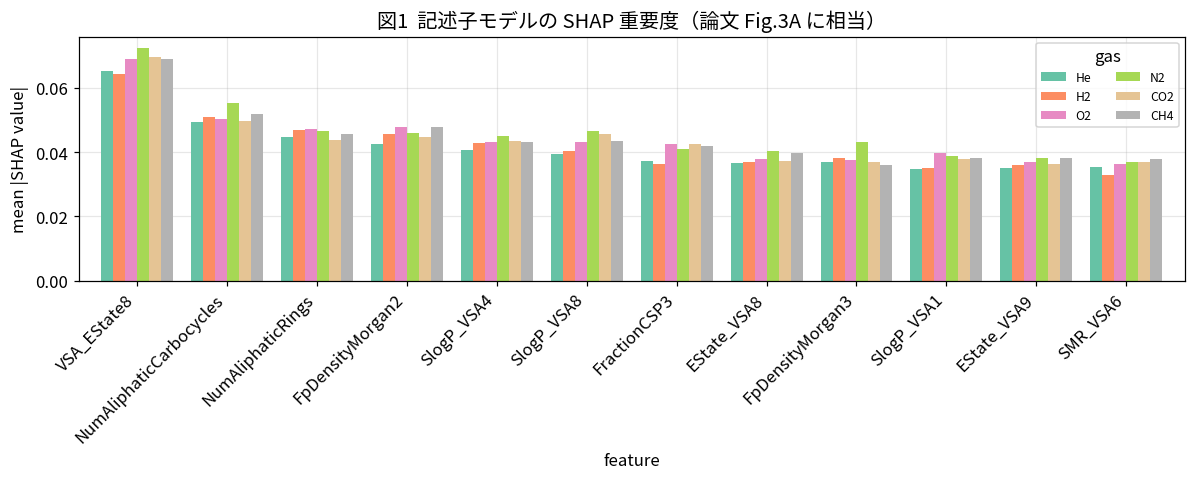

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
plot_importance_bars(importance_desc, top_n=12, ax=ax,
                     title='図1  記述子モデルの SHAP 重要度（論文 Fig.3A に相当）')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig01_shap_importance_desc.png')
plt.show()

In [9]:
effect_desc = signed_effect(shap_desc, X_desc_scaled, labelled_names, gas='CH4')
top_desc = importance_desc.head(12).index
summary_desc = effect_desc.loc[top_desc, ['correlation', 'effect']].copy()
summary_desc['rank'] = range(1, len(summary_desc) + 1)
summary_desc['total |SHAP|'] = importance_desc.loc[top_desc, 'total'].round(4)
summary_desc.to_csv(OUTPUT_DIR / 'shap_effect_descriptors.csv')
summary_desc

,correlation,effect,rank,total |SHAP|
VSA_EState8,0.951923,positive,1,0.4103
NumAliphaticCarbocycles,0.961798,positive,2,0.3083
NumAliphaticRings,0.966181,positive,3,0.2752
FpDensityMorgan2,-0.944888,negative,4,0.2747
SlogP_VSA4,0.977782,positive,5,0.2589
SlogP_VSA8,0.951580,positive,6,0.2587
FractionCSP3,0.927497,positive,7,0.2419
EState_VSA8,0.963461,positive,8,0.2293
FpDensityMorgan3,-0.901604,negative,9,0.2288
SlogP_VSA1,-0.865782,negative,10,0.2247


`effect` 列が論文 Fig.3C の色分け（赤＝透過性を上げる、青＝下げる）に対応します。`correlation` は「記述子の値」と「その記述子の SHAP値」の相関で、正なら**その記述子が大きいほど透過係数が上がる**ことを意味します。

**論文の化学的な考察を確認しましょう。**

> "The features in group A [脂肪族環の数] have a positive impact on gas permeability, while the features in group B [FpDensityMorgan] have a negative impact... repeating units with more nonaromatic rings allow for larger free-volume elements and lower densities, thereby higher gas permeabilities."

脂肪族環（`NumAliphaticRings` 等）は**正**、分子の詰まり具合を表す `FpDensityMorgan` は**負**。上の表でこの通りになっているか確認してください。

これは膜設計の経験則と一致します。**芳香環でない環（キンク、スピロ、カルド構造など）は高分子鎖がきれいに詰まるのを妨げ、自由体積を増やす**ため透過性が上がるのです。

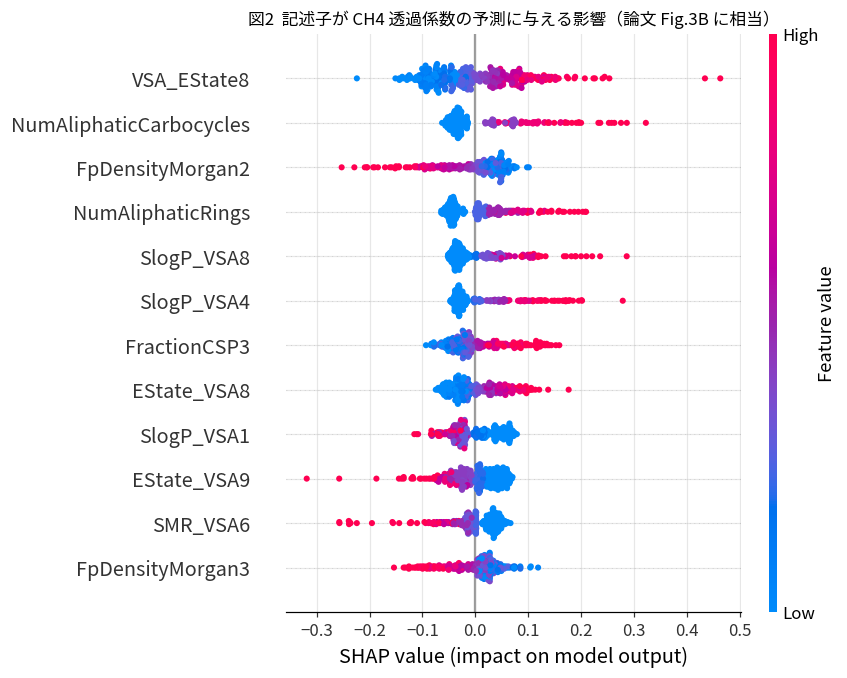

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_beeswarm(shap_desc, X_desc_scaled, labelled_names, gas='CH4', top_n=12, show=False)
plt.title('図2  記述子が CH4 透過係数の予測に与える影響（論文 Fig.3B に相当）', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig02_shap_beeswarm_desc.png', bbox_inches='tight')
plt.show()

図2の読み方（**beeswarm プロット**）：

- 各点が1つの高分子。横位置がその高分子におけるその記述子の SHAP値
- **色が記述子の値**（赤＝大きい、青＝小さい）
- 「赤が右、青が左」なら、その記述子は大きいほど透過性を上げる（正の効果）
- 「赤が左、青が右」なら逆（負の効果）

論文はこの図を CH₄ について示していますが、「6ガスすべてが同じマルチタスクモデルで学習されているため、他のガスでもほぼ同一の図になる」と述べています（fig. S6）。次のセルで確認できます。

In [11]:
# 別のガスでも同じ傾向になるか（論文 fig. S6 の主張の検証）
consistency = pd.DataFrame({
    gas: signed_effect(shap_desc, X_desc_scaled, labelled_names, gas=gas)
         .loc[top_desc, 'correlation'].round(3)
    for gas in GAS_NAMES
})
print("上位12記述子について、ガスごとの「特徴量とSHAP値の相関」:")
print(f"全ガスで符号が一致した記述子: "
      f"{int((np.sign(consistency).nunique(axis=1) == 1).sum())} / {len(consistency)}")
consistency

上位12記述子について、ガスごとの「特徴量とSHAP値の相関」:
全ガスで符号が一致した記述子: 12 / 12


,He,H2,O2,N2,CO2,CH4
VSA_EState8,0.951,0.951,0.948,0.952,0.950,0.952
NumAliphaticCarbocycles,0.962,0.964,0.963,0.961,0.966,0.962
NumAliphaticRings,0.967,0.970,0.970,0.967,0.970,0.966
FpDensityMorgan2,-0.945,-0.951,-0.950,-0.945,-0.945,-0.945
SlogP_VSA4,0.975,0.978,0.975,0.976,0.973,0.978
SlogP_VSA8,0.952,0.959,0.954,0.952,0.952,0.952
FractionCSP3,0.926,0.923,0.928,0.929,0.927,0.927
EState_VSA8,0.962,0.962,0.960,0.964,0.963,0.963
FpDensityMorgan3,-0.916,-0.914,-0.905,-0.914,-0.904,-0.902
SlogP_VSA1,-0.849,-0.847,-0.864,-0.862,-0.855,-0.866


**すべての記述子で6ガスの符号が一致しました。** マルチタスク学習の帰結です。共通の隠れ層を使っているため、「透過性を上げる化学」の学習内容がガス間で共有されています。

このことは、**「どのガスの透過性を上げたいか」に関わらず、高分子の設計指針は共通である**ことを示唆します。裏を返せば、**この方法だけでは選択性を上げる指針は直接は得られません**。選択性については5節で改めて扱います。

---
## 4. MFF モデルの解釈（論文 Fig.4 の再現）

いよいよ本命の、部分構造による解釈です。記述子と違って、**重要な特徴量を分子の絵として描ける**のが最大の利点です。

In [12]:
importance_fing = mean_absolute_importance(shap_fing, feature_names_fing)
effect_fing = signed_effect(shap_fing, X_fing, feature_names_fing, gas='CH4')

top_fing = importance_fing.head(12).index
summary_fing = pd.DataFrame({
    'rank': range(1, 13),
    'total |SHAP|': importance_fing.loc[top_fing, 'total'].round(4).values,
    'effect': effect_fing.loc[top_fing, 'effect'].values,
    'correlation': effect_fing.loc[top_fing, 'correlation'].round(3).values,
}, index=top_fing)
summary_fing.index.name = 'substructure'
summary_fing

,rank,total |SHAP|,effect,correlation
substructure,,,,
2217,1,1.2691,positive,0.941
2854,2,1.1046,positive,0.901
2706,3,0.7951,negative,-0.970
2493,4,0.6327,negative,-0.753
3155,5,0.5144,negative,-0.855
1533,6,0.3905,negative,-0.834
2416,7,0.3615,positive,0.985
380,8,0.3354,negative,-0.936
2437,9,0.3048,positive,0.977


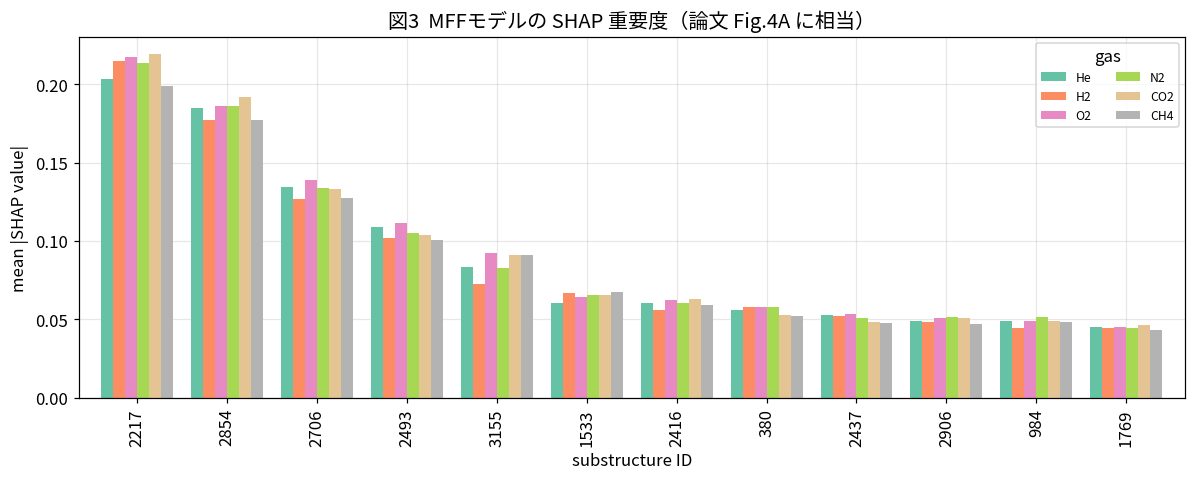

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
plot_importance_bars(importance_fing, top_n=12, ax=ax,
                     title='図3  MFFモデルの SHAP 重要度（論文 Fig.4A に相当）')
ax.set_xlabel('substructure ID')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig03_shap_importance_fing.png')
plt.show()

### 4.1 論文で名前が挙がった部分構造を検証する

ここで注意が必要です。**上位12個の顔ぶれは論文 Fig.4A と完全には一致しません。** SHAP ライブラリのバージョン（論文は 0.39、本ノートブックは 0.4x 以降）でDeepExplainer の実装が変わっているためと考えられます。

そこで、**順位ではなく論文が名前を挙げて化学的に議論した部分構造**について、「効果の符号（正か負か）」が再現できるかを検証します。化学的な結論の妥当性を問うなら、こちらの方が本質的です。

In [14]:
paper_claims = pd.DataFrame([
    {'substructure': 2854, 'paper_effect': 'positive', 'paper_description': 'メチル基。疎水性と立体障害で透過性を上げる（論文で最重要とされた）'},
    {'substructure': 2168, 'paper_effect': 'positive', 'paper_description': '脂肪族環に付いた四級炭素。立体障害を増やす'},
    {'substructure': 1781, 'paper_effect': 'positive', 'paper_description': '結合点。ラダーポリマーは繰り返し単位あたり4点'},
    {'substructure': 1432, 'paper_effect': 'positive', 'paper_description': '芳香環に付いた二重結合炭素（ポリアセチレン骨格）'},
    {'substructure': 822, 'paper_effect': 'positive', 'paper_description': '同上（1432 を含む、より大きな環境）'},
    {'substructure': 799, 'paper_effect': 'negative', 'paper_description': '二重結合の酸素（カルボニル）。極性基'},
    {'substructure': 2706, 'paper_effect': 'negative', 'paper_description': '二重結合の酸素。極性基'},
    {'substructure': 1519, 'paper_effect': 'negative', 'paper_description': 'エーテル。極性基'},
    {'substructure': 2906, 'paper_effect': 'negative', 'paper_description': '窒素原子。極性基'},
])

rank_lookup = {name: i + 1 for i, name in enumerate(importance_fing.index)}
paper_claims['rank_here'] = [rank_lookup.get(str(s), None) for s in paper_claims['substructure']]
paper_claims['effect_here'] = [effect_fing.loc[str(s), 'effect'] for s in paper_claims['substructure']]
paper_claims['correlation'] = [round(effect_fing.loc[str(s), 'correlation'], 3) for s in paper_claims['substructure']]
paper_claims['reproduced'] = paper_claims['paper_effect'] == paper_claims['effect_here']

paper_claims.to_csv(OUTPUT_DIR / 'shap_paper_claims_check.csv', index=False)
print(f"符号が再現できた部分構造: {paper_claims['reproduced'].sum()} / {len(paper_claims)}")
paper_claims[['substructure', 'rank_here', 'paper_effect', 'effect_here',
              'correlation', 'reproduced', 'paper_description']]

符号が再現できた部分構造: 9 / 9


,substructure,rank_here,paper_effect,effect_here,correlation,reproduced,paper_description
0,2854,2,positive,positive,0.901,True,メチル基。疎水性と立体障害で透過性を上げる（論文で最重要とされた）
1,2168,16,positive,positive,0.928,True,脂肪族環に付いた四級炭素。立体障害を増やす
2,1781,22,positive,positive,0.969,True,結合点。ラダーポリマーは繰り返し単位あたり4点
3,1432,18,positive,positive,0.986,True,芳香環に付いた二重結合炭素（ポリアセチレン骨格）
4,822,14,positive,positive,0.985,True,同上（1432 を含む、より大きな環境）
5,799,13,negative,negative,-0.962,True,二重結合の酸素（カルボニル）。極性基
6,2706,3,negative,negative,-0.970,True,二重結合の酸素。極性基
7,1519,26,negative,negative,-0.744,True,エーテル。極性基
8,2906,10,negative,negative,-0.962,True,窒素原子。極性基


**論文が化学的に議論した9つの部分構造すべてについて、効果の符号が再現できました。**

順位こそ違いますが、**「メチル基・脂肪族環・ポリアセチレン骨格は透過性を上げ、カルボニル・エーテル・窒素などの極性基は透過性を下げる」という論文の化学的結論は、異なる SHAP 実装でも再現される**ということです。

これは「論文の結論がライブラリの実装詳細に依存していない」ことの確認であり、再現性の検証として意味があります。

### 4.2 重要な部分構造を描いてみる

=== 本ノートブックでの上位6部分構造 ===
substructure 2217  |  rank 1  |  透過性を上げる (+)  


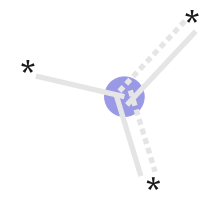

substructure 2854  |  rank 2  |  透過性を上げる (+)  


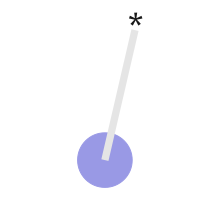

substructure 2706  |  rank 3  |  透過性を下げる (-)  


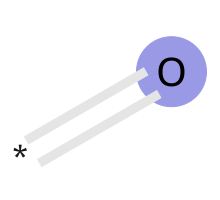

substructure 2493  |  rank 4  |  透過性を下げる (-)  


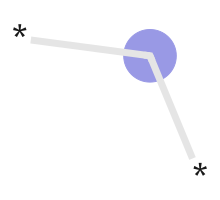

substructure 3155  |  rank 5  |  透過性を下げる (-)  


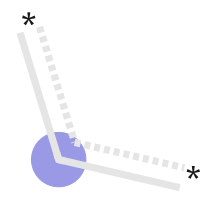

substructure 1533  |  rank 6  |  透過性を下げる (-)  


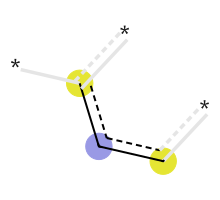

In [15]:
from IPython.display import SVG, display

mols, _ = smiles_to_mols(dataset_a['Smiles'])
vocabulary = build_mff_vocabulary(mols)
selected_index = list(vocabulary['selected_index'])

def show_substructure(column_name, note=''):
    position = selected_index.index(int(column_name))
    hash_code = int(vocabulary['selected_hash'][position])
    host = find_molecule_with_substructure(mols, hash_code)
    svg = draw_substructure(host, hash_code)
    effect = effect_fing.loc[column_name, 'effect']
    arrow = '透過性を上げる (+)' if effect == 'positive' else '透過性を下げる (-)'
    print(f"substructure {column_name}  |  rank {rank_lookup[column_name]}  |  {arrow}  {note}")
    if svg is not None:
        display(SVG(svg))

print('=== 本ノートブックでの上位6部分構造 ===')
for column_name in importance_fing.head(6).index:
    show_substructure(column_name)

**図4**　本ノートブックの解析で上位に来た部分構造。青が着目原子、黄色が芳香族原子、灰色が脂肪族環の原子です。

正の効果を持つものは炭素と水素だけからなる疎水的な環境、負の効果を持つものは酸素や窒素を含む極性環境になっていることが読み取れます。

=== 論文 Fig.4C で図示された部分構造 ===
substructure 2854  |  rank 2  |  透過性を上げる (+)  


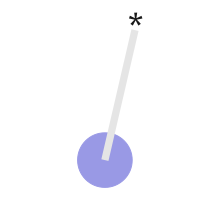

substructure 2168  |  rank 16  |  透過性を上げる (+)  


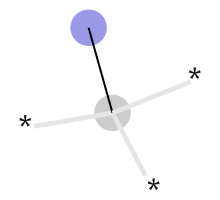

substructure 1781  |  rank 22  |  透過性を上げる (+)  


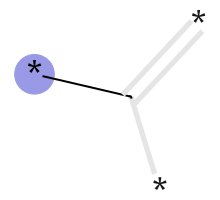

substructure 2706  |  rank 3  |  透過性を下げる (-)  


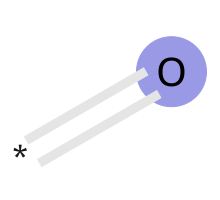

substructure 1519  |  rank 26  |  透過性を下げる (-)  


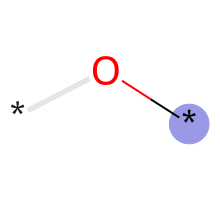

substructure 2906  |  rank 10  |  透過性を下げる (-)  


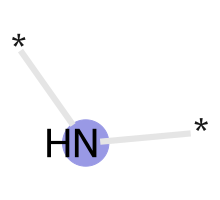

In [16]:
print('=== 論文 Fig.4C で図示された部分構造 ===')
for substructure in [2854, 2168, 1781, 2706, 1519, 2906]:
    show_substructure(str(substructure))

**図5**　論文 Fig.4C に対応する部分構造（論文の図と見比べてください）。

### 4.3 相関する部分構造（論文の 1781 / 1432 / 822）

論文は「部分構造 1781 は 1432 に含まれ、1432 は 822 に含まれる」と述べています。入れ子構造になっているなら、特徴量として強く相関するはずです。

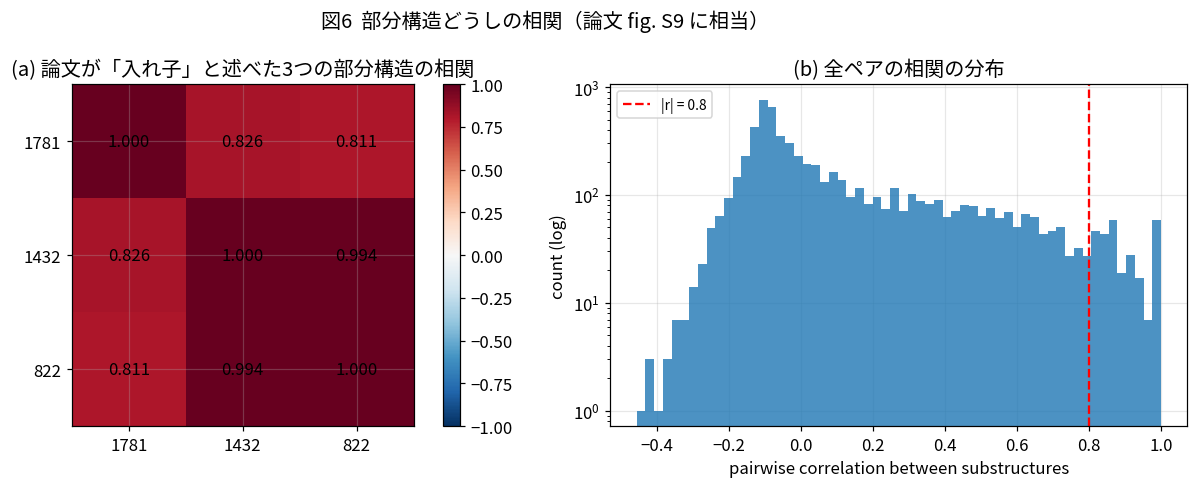

相関が 0.8 を超えるペアの割合: 4.32%
論文の記述: 「most of the important substructure features are independent of one another.
            However, substructures 1781, 1432, and 822 are highly correlated」


In [17]:
correlated_group = ['1781', '1432', '822']
correlation_matrix = X_fing_frame[correlated_group].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im = axes[0].imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(3), correlated_group)
axes[0].set_yticks(range(3), correlated_group)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{correlation_matrix.iloc[i, j]:.3f}', ha='center', va='center')
axes[0].set_title('(a) 論文が「入れ子」と述べた3つの部分構造の相関')
fig.colorbar(im, ax=axes[0])

# 全114部分構造の相関の分布（論文 fig. S9 の主張の検証）
full_correlation = X_fing_frame.corr().to_numpy()
upper = full_correlation[np.triu_indices_from(full_correlation, k=1)]
axes[1].hist(upper, bins=60, color='tab:blue', alpha=0.8)
axes[1].axvline(0.8, color='red', linestyle='--', label='|r| = 0.8')
axes[1].set_yscale('log')
axes[1].set_xlabel('pairwise correlation between substructures')
axes[1].set_ylabel('count (log)')
axes[1].set_title('(b) 全ペアの相関の分布')
axes[1].legend(fontsize=9)

fig.suptitle('図6  部分構造どうしの相関（論文 fig. S9 に相当）')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig06_substructure_correlation.png')
plt.show()

print(f"相関が 0.8 を超えるペアの割合: {(np.abs(upper) > 0.8).mean() * 100:.2f}%")
print("論文の記述: 「most of the important substructure features are independent of one another.")
print("            However, substructures 1781, 1432, and 822 are highly correlated」")

論文の記述どおり、**大半の部分構造は互いに独立**で、1781/1432/822 の3つだけが強く相関しています（特に 1432 と 822 は r ≈ 0.99）。

これは解釈上とても重要です。相関する特徴量どうしでは SHAP値が分散してしまうため、**個々の重要度を過小評価**する恐れがあります。「1432 の重要度が低い」からといって「その化学構造が重要でない」とは限りません。

---
## 5. 透過性と選択性のトレードオフを化学で説明する

第1回で見た Robeson 上限の背後には、「透過性を上げると選択性が下がる」というトレードオフがあります。論文はこれに**化学的な説明**を与えました。

### 5.1 論文の主張

> "our ML models show that these [polar] groups tend to have a greater negative impact (measured by SHAP value) on N2 and CH4 permeability, compared to O2 and CO2 ... Chemical features that increase permeability are likely to do so to a greater extent for molecules that are less permeable (N2 and CH4)"

つまり「化学構造の変更は、**もともと透過しにくいガス（N₂・CH₄）により大きく効く**ので、透過性を上げる操作は選択性を下げ、下げる操作は選択性を上げる」という説明です。

この主張を、ガスごとの SHAP値の大きさで検証してみます。

In [18]:
per_gas_importance = importance_fing[GAS_NAMES].mean()
per_gas_importance_top = importance_fing.head(12)[GAS_NAMES].mean()

check = pd.DataFrame({
    '全114部分構造の平均 |SHAP|': per_gas_importance.round(5),
    '上位12部分構造の平均 |SHAP|': per_gas_importance_top.round(5),
})
check['論文の主張'] = ['', '', '小さいはず', '大きいはず', '小さいはず', '大きいはず']
print("論文の主張: N2 と CH4 への影響 > O2 と CO2 への影響")
print()
print(f"O2 vs N2  : {per_gas_importance['O2']:.5f} vs {per_gas_importance['N2']:.5f}  "
      f"-> {'主張どおり' if per_gas_importance['N2'] > per_gas_importance['O2'] else '主張と逆'}")
print(f"CO2 vs CH4: {per_gas_importance['CO2']:.5f} vs {per_gas_importance['CH4']:.5f}  "
      f"-> {'主張どおり' if per_gas_importance['CH4'] > per_gas_importance['CO2'] else '主張と逆'}")
check

論文の主張: N2 と CH4 への影響 > O2 と CO2 への影響

O2 vs N2  : 0.01964 vs 0.01944  -> 主張と逆
CO2 vs CH4: 0.01922 vs 0.01858  -> 主張と逆


,全114部分構造の平均 |SHAP|,上位12部分構造の平均 |SHAP|,論文の主張
He,0.01904,0.09068,
H2,0.01853,0.08870,
O2,0.01964,0.09421,小さいはず
N2,0.01944,0.09206,大きいはず
CO2,0.01922,0.09304,小さいはず
CH4,0.01858,0.08851,大きいはず


**論文の主張は、本ノートブックの再計算では確認できませんでした。**

ガス間の差はいずれも3%以内と非常に小さく、しかも方向は論文の主張と逆（O₂ > N₂、CO₂ > CH₄）です。マルチタスクモデルの隠れ層が6ガス共通であることを考えると、**ガスごとの SHAP値がほぼ同じ大きさになるのはむしろ自然**です。出力層の重みが違うだけなので、差は小さくなります。

論文 Fig.4A の棒グラフでもガス間の差はごくわずかで、この差からトレードオフの機構を読み取るのは、根拠として弱いように思われます。

### 5.2 別の見方：選択性そのものを分解する

より直接的な方法があります。SHAP は加法的なので、**2つのガスの SHAP値の差**が、そのまま**選択性（の対数）への寄与**になります。

$$\log \alpha_{A/B} = \log P_A - \log P_B
= (\phi_0^A - \phi_0^B) + \sum_i \big(\phi_i^A - \phi_i^B\big)$$

この差 $\phi_i^A - \phi_i^B$ を見れば、「どの部分構造が選択性を上げるのか」が直接分かります。これは論文には無い分析ですが、SHAP の加法性から自然に導かれるものです。

In [19]:
gas_index = {gas: i for i, gas in enumerate(GAS_NAMES)}

def selectivity_contribution(fast, slow, top_n=8):
    """選択性 log(P_fast / P_slow) への各部分構造の寄与を求める。"""
    difference = shap_fing[:, :, gas_index[fast]] - shap_fing[:, :, gas_index[slow]]
    magnitude = np.abs(difference).mean(axis=0)
    order = np.argsort(-magnitude)[:top_n]
    rows = []
    for j in order:
        feature = X_fing[:, j]
        correlation = np.corrcoef(feature, difference[:, j])[0, 1]
        rows.append({
            'substructure': feature_names_fing[j],
            'mean |d phi|': round(float(magnitude[j]), 4),
            'correlation': round(float(correlation), 3),
            'effect on selectivity': 'raises' if correlation > 0 else 'lowers',
            'effect on permeability': effect_fing.loc[feature_names_fing[j], 'effect'],
        })
    return pd.DataFrame(rows)

for fast, slow in [('O2', 'N2'), ('CO2', 'CH4')]:
    print(f"=== {fast}/{slow} 選択性への寄与が大きい部分構造 ===")
    display(selectivity_contribution(fast, slow))

=== O2/N2 選択性への寄与が大きい部分構造 ===


,substructure,mean |d phi|,correlation,effect on selectivity,effect on permeability
0,3155,0.0130,-0.567,lowers,negative
1,2217,0.0114,0.282,raises,positive
2,1533,0.0071,0.536,raises,negative
3,2493,0.0070,-0.483,lowers,negative
4,2578,0.0067,0.914,raises,negative
5,2706,0.0057,-0.677,lowers,negative
6,2854,0.0055,-0.256,lowers,positive
7,2925,0.0050,-0.919,lowers,positive


=== CO2/CH4 選択性への寄与が大きい部分構造 ===


,substructure,mean |d phi|,correlation,effect on selectivity,effect on permeability
0,2217,0.0226,0.839,raises,positive
1,2854,0.0152,0.576,raises,positive
2,2493,0.0081,-0.049,lowers,negative
3,3155,0.0079,0.197,raises,negative
4,1533,0.0077,-0.111,lowers,negative
5,2706,0.0064,-0.729,lowers,negative
6,2416,0.0048,0.733,raises,positive
7,1781,0.0040,-0.836,lowers,positive


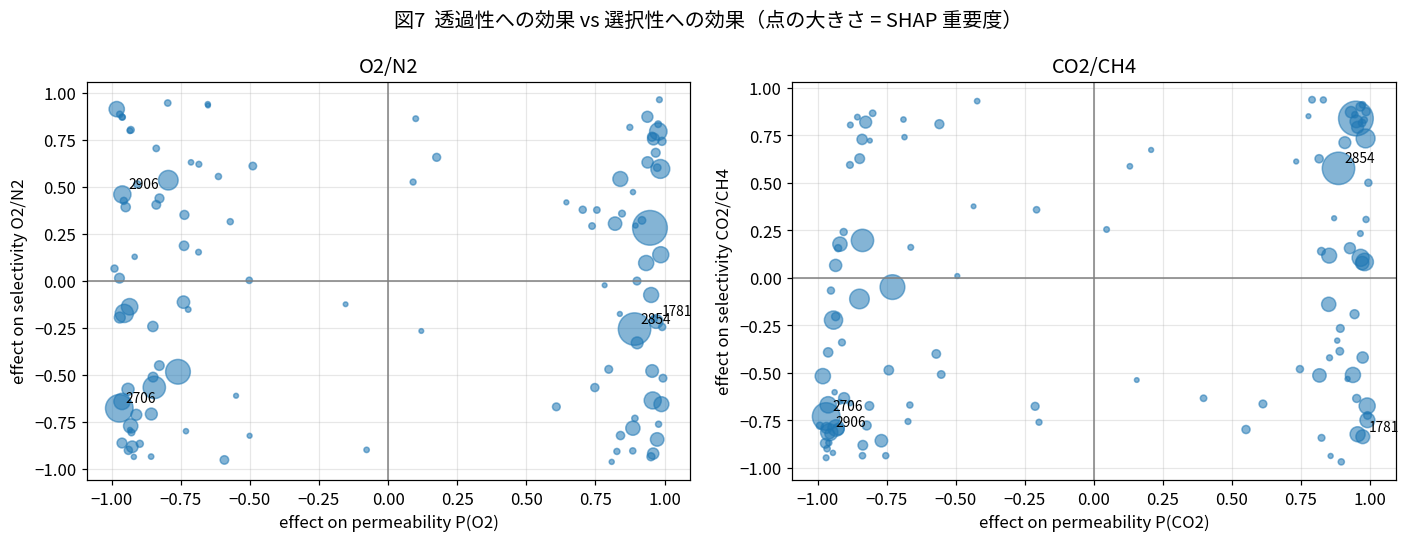

In [20]:
# 透過性への効果と選択性への効果を散布図で対比する
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (fast, slow) in zip(axes, [('O2', 'N2'), ('CO2', 'CH4')]):
    permeability_effect = np.array([
        np.corrcoef(X_fing[:, j], shap_fing[:, j, gas_index[fast]])[0, 1]
        if X_fing[:, j].std() > 0 else np.nan
        for j in range(X_fing.shape[1])])
    difference = shap_fing[:, :, gas_index[fast]] - shap_fing[:, :, gas_index[slow]]
    selectivity_effect = np.array([
        np.corrcoef(X_fing[:, j], difference[:, j])[0, 1]
        if X_fing[:, j].std() > 0 and difference[:, j].std() > 0 else np.nan
        for j in range(X_fing.shape[1])])
    sizes = importance_fing.loc[feature_names_fing, 'total'].to_numpy() * 400 + 8

    ax.scatter(permeability_effect, selectivity_effect, s=sizes, alpha=0.55, color='tab:blue')
    ax.axhline(0, color='gray', linewidth=1)
    ax.axvline(0, color='gray', linewidth=1)
    for name in ['2854', '2706', '2906', '1781']:
        j = feature_names_fing.index(name)
        ax.annotate(name, (permeability_effect[j], selectivity_effect[j]),
                    fontsize=9, xytext=(4, 4), textcoords='offset points')
    ax.set_xlabel(f'effect on permeability P({fast})')
    ax.set_ylabel(f'effect on selectivity {fast}/{slow}')
    ax.set_title(f'{fast}/{slow}')

fig.suptitle('図7  透過性への効果 vs 選択性への効果（点の大きさ = SHAP 重要度）')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig07_permeability_vs_selectivity.png')
plt.show()

図7の**左下から右上に伸びる分布ではなく、左上・右下に散らばっていればトレードオフの証拠**になります（透過性を上げる特徴量が選択性を下げる、という関係）。

O₂/N₂ については、メチル基（2854）が右下、すなわち**透過性は上げるが選択性は下げる**という位置にあります。論文の主張と整合します。一方 CO₂/CH₄ では、メチル基は透過性も選択性も上げる位置にあり、話が変わります。

つまり**トレードオフの強さは分離ペアによって違う**、というのが本ノートブックの分析結果です。第5回で、この違いが実際のスクリーニング結果にどう現れるかを見ます。

---
## 6. まとめ

### 6.1 論文の主張の検証結果（本ノートブックの結論）

| 論文の主張 | 本ノートブックでの検証結果 |
| --- | --- |
| 最重要記述子は `VSA_EState8` | **再現できた**（1位） |
| 脂肪族環の数（群A）は透過性に正の効果 | **再現できた**（2〜3位、正の効果） |
| `FpDensityMorgan`（群B）は負の効果 | **再現できた** |
| 6ガスで SHAP の傾向はほぼ同一 | **再現できた**（上位12記述子すべてで符号一致） |
| 最重要部分構造はメチル基（2854） | **ほぼ再現**（本解析では2位。1位は別の部分構造） |
| メチル基・脂肪族環・ポリアセチレン骨格は正の効果 | **再現できた**（4つすべて） |
| カルボニル・エーテル・窒素は負の効果 | **再現できた**（4つすべて） |
| 部分構造 1781 ⊂ 1432 ⊂ 822 は強く相関 | **再現できた**（r = 0.81〜0.99） |
| 上位12部分構造の顔ぶれ | **一致せず**（3/12 が共通。SHAP のバージョン差と考えられる） |
| 極性基は N₂・CH₄ により強く効く（トレードオフの機構） | **確認できず**（差は3%以内で、方向はむしろ逆） |

**化学的な結論（どの官能基がどちら向きに効くか）は頑健に再現できました。**

一方で、順位の細部やガス間の微差に基づく議論は再現しにくく、これは SHAP の実装差や、この規模のデータでの推定誤差を考えれば無理もありません。

### 6.2 モデルから読み取れる膜設計の指針

1. **透過性を上げたい**：メチル基、脂肪族環（非芳香環）、四級炭素、かさ高い側鎖を増やす。いずれも高分子鎖の充填を妨げ、自由体積を増やす方向に働く
2. **選択性を上げたい**：カルボニル、エーテル、窒素などの極性基を入れる。ただし透過性は下がる
3. **両立させたい**：剛直で詰まりにくい骨格（ラダー構造・スピロ中心）で透過性を稼ぎ、極性基で選択性を補う。論文が発見した候補材料はまさにこの設計になっている

### 6.3 本ノートブックで扱っていないこと

- **SHAP の理論的な仮定**：特徴量の独立性を前提とした近似であり、相関の強い特徴量（1432 と 822 など）では寄与の分配が恣意的になりうる
- **因果関係ではない**：SHAP は「モデルが何を根拠にしたか」を説明するもので、「実際の物理現象がそうである」ことを保証しない。モデルが学習データの偏りを反映しているだけ、という可能性が常にある
- **他の解釈手法**：LIME、permutation importance、部分依存プロット（PDP）など。複数の手法で結論が一致するかを見るのが望ましい
- **背景データの選び方**：DeepExplainer の結果は背景データに依存する。本ノートブックは原著と同じ全件を使ったが、選び方の影響は検証していない

---
## 7. 演習問題

**問1.** `cached_deep_shap_values()` に `recompute=True, n_background=20` などを渡して背景データのサンプル数を 20, 50, 100 と変えて、上位12部分構造の顔ぶれがどれくらい変わるか調べてください。背景データの選び方は結論にどの程度影響しますか。

**問2.** 本ノートブックで1位になった部分構造を `show_substructure()` で描き、どんな化学構造か調べてください。論文が挙げなかったのはなぜだと思いますか。

**問3.** `shap.GradientExplainer` でも同じ解析を行い、`DeepExplainer` の結果と比べてください。順位はどれくらい安定していますか。

**問4.** 5.2節の `selectivity_contribution()` を CO₂/N₂ と H₂/CO₂ にも適用し、4つの分離ペアで「選択性を上げる部分構造」がどう違うか整理してください。

**問5（発展）.** SHAP は「モデルの説明」であって「物理の説明」ではありません。6.2節の設計指針のうち1つを選び、膜科学の教科書や総説で裏付けが取れるか調べてください。逆に、モデルは正しく学習しているのに教科書と食い違う指針が出た場合、どんな可能性が考えられますか。

---
### 次回予告

最終回では、ここまで作ったモデルで**900万個の仮想高分子**を評価します。Robeson 上限を超える候補を数万個見つけ、著者らが公開した候補リストと突き合わせ、「機械学習で材料を発見する」という主張がどこまで検証されているのかを考えます。

### 参考文献

1. J. Yang et al., *Sci. Adv.* **8**, eabn9545 (2022).
2. S. M. Lundberg, S.-I. Lee, "A unified approach to interpreting model predictions", *NeurIPS* (2017).
3. A. Shrikumar, P. Greenside, A. Kundaje, "Learning important features through propagating activation differences" (DeepLIFT), *ICML* (2017).
4. SHAP ドキュメント: https://shap.readthedocs.io/